# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### 1. Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

Used car dealerships operate within a highly competitive market where pricing decisions directly affect profitability and inventory turnover. Overpricing can lead to stagnant inventory and lost sales; underpricing erodes profit margins.

# Business Problem #
Identify the features and attributes (e.g. age, odometry, brand) that strongly affect the price of a car so that used car dealers can:
- make informed acquisition decisions at auctions and for trade-ins
- set competitive, data-driven prices for inventory
- optimize inventory mix by understanding which vehicle attributes command premium prices
- provide transparent, defensible valuations to customers

# Machine Learning Framing #
Per this **supervised learning** task
- predict a continuous target variable - price - based on vehicle attributes e.g. year, odometer reading, condition, etc.
- build interpretable models to predict price accurately and quantify marginal effect of each feature, to identify price drivers


,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
126,7305672709,auburn,0,2018.0,chevrolet,express cargo van,like new,6 cylinders,gas,68472.0,clean,automatic,1GCWGAFP8J1309579,rwd,full-size,van,white,al
127,7305672266,auburn,0,2019.0,chevrolet,express cargo van,like new,6 cylinders,gas,69125.0,clean,automatic,1GCWGAFP4K1214373,rwd,full-size,van,white,al
128,7305672252,auburn,0,2018.0,chevrolet,express cargo van,like new,6 cylinders,gas,66555.0,clean,automatic,1GCWGAFPXJ1337903,rwd,full-size,van,white,al
215,7316482063,birmingham,4000,2002.0,toyota,echo,excellent,4 cylinders,gas,155000.0,clean,automatic,JTDBT123520243495,fwd,compact,sedan,blue,al
219,7316429417,birmingham,2500,1995.0,bmw,525i,fair,6 cylinders,gas,110661.0,clean,automatic,WBAHD6322SGK86772,rwd,mid-size,sedan,white,al


### 2. Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [120]:
## Import needed libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, TargetEncoder

### 2.1 Data Loading and Initial Inspection

In [43]:
vehicles = pd.read_csv('data/vehicles.csv')

vehicles.shape
vehicles.describe(include=np.number)


,id,price,year,odometer
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07


### 2.2 Investigate dataset for missing or problematic data ###

In [44]:
def data_quality_report(df):
  return pd.DataFrame({
    'data_type': df.dtypes,
    'non_null_count': df.notnull().sum(),
    'null_count': df.isnull().sum(),
    'null_percentage': (df.isnull().sum() / len(df)) * 100,
    'unique_values': df.nunique(),
    'sample_value': df.sample().iloc[0]
  })

data_quality_report(vehicles)

,data_type,non_null_count,null_count,null_percentage,unique_values,sample_value
id,int64,426880,0,0.000000,426880,7308295881
region,object,426880,0,0.000000,404,oklahoma city
price,int64,426880,0,0.000000,15655,0
year,float64,425675,1205,0.282281,114,2006.0
manufacturer,object,409234,17646,4.133714,42,kia
model,object,421603,5277,1.236179,29649,spectra
condition,object,252776,174104,40.785232,6,NaN
cylinders,object,249202,177678,41.622470,8,NaN
fuel,object,423867,3013,0.705819,5,gas
odometer,float64,422480,4400,1.030735,104870,NaN


### 2.3 Target Variable: Price ###

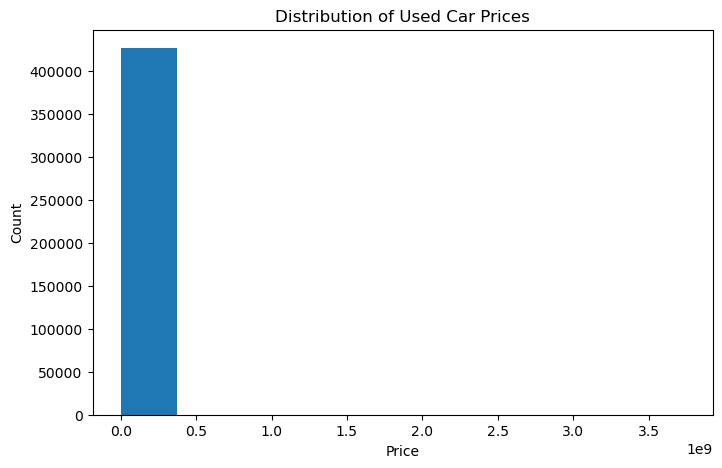

In [45]:
plt.figure(figsize=(8,5))
plt.hist(vehicles['price'])
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

### 2.4 Removal of Price Outliers, Outstanding Columns ###

Due to extreme left skew of data, remove outliers using reasonable boundaries of $500 minimum and $200,000 maximum.

Condition, cylinders, and size are removed due outstanding missing values.

In [46]:
lower_bound = 500
upper_bound = 200_000

vehicles_clean = vehicles[(vehicles['price'] >= 500) & (vehicles['price'] <= 200_000)].drop(columns=['condition', 'cylinders', 'size', 'drive'])

vehicles_clean.shape
vehicles_clean.info

<bound method DataFrame.info of                 id                  region  price    year manufacturer  \
0       7222695916                prescott   6000     NaN          NaN   
1       7218891961            fayetteville  11900     NaN          NaN   
2       7221797935            florida keys  21000     NaN          NaN   
3       7222270760  worcester / central MA   1500     NaN          NaN   
4       7210384030              greensboro   4900     NaN          NaN   
...            ...                     ...    ...     ...          ...   
426875  7301591192                 wyoming  23590  2019.0       nissan   
426876  7301591187                 wyoming  30590  2020.0        volvo   
426877  7301591147                 wyoming  34990  2020.0     cadillac   
426878  7301591140                 wyoming  28990  2018.0        lexus   
426879  7301591129                 wyoming  30590  2019.0          bmw   

                           model    fuel  odometer title_status transmission  \

Now, we look at the distribution of used car prices.

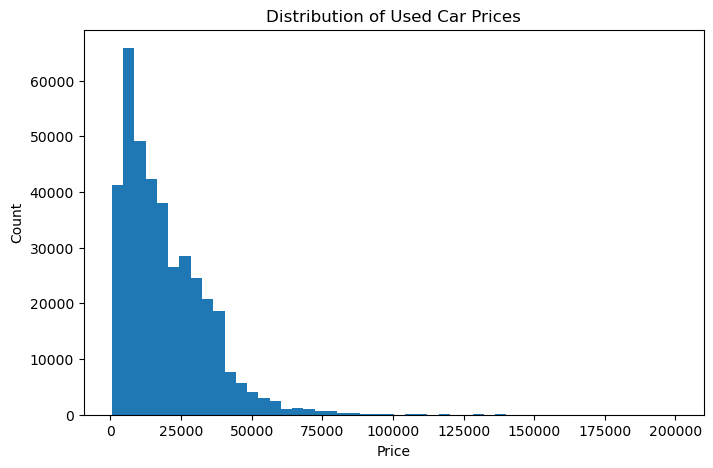

In [47]:
plt.figure(figsize=(8,5))
plt.hist(vehicles_clean['price'], bins=50)
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()


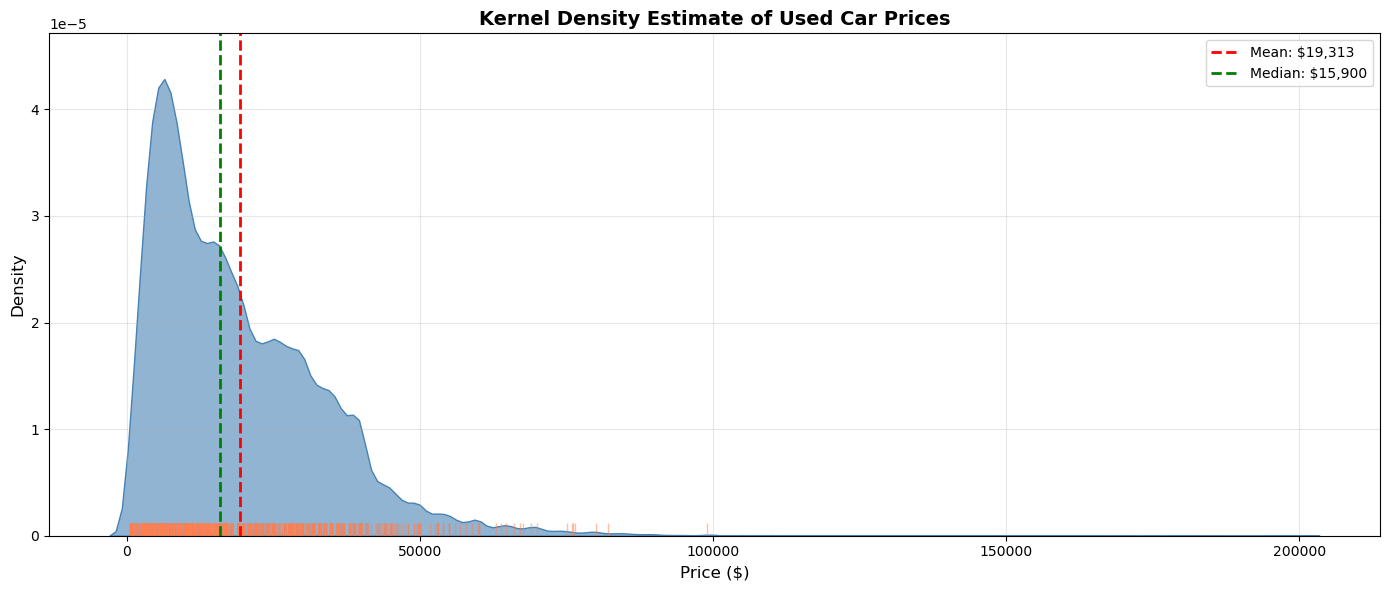

In [48]:
## KDE Plot for Used Car Prices 
fig, ax = plt.subplots(figsize=(14, 6))

# KDE plot
sns.kdeplot(data=vehicles_clean, x='price', fill=True, color='steelblue', alpha=0.6, ax=ax)

# Add rug plot (small vertical lines for each data point) - sample for performance
sample = vehicles_clean.sample(min(1000, len(vehicles_clean)), random_state=42)
sns.rugplot(data=sample, x='price', color='coral', alpha=0.5, ax=ax)

# Add mean and median lines
ax.axvline(vehicles_clean['price'].mean(), color='red', linestyle='--', 
           linewidth=2, label=f"Mean: ${vehicles_clean['price'].mean():,.0f}")
ax.axvline(vehicles_clean['price'].median(), color='green', linestyle='--', 
           linewidth=2, label=f"Median: ${vehicles_clean['price'].median():,.0f}")

ax.set_xlabel("Price ($)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Kernel Density Estimate of Used Car Prices", fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.5 Univariate Analysis for Numeric Features 

In [19]:
# Select numeric columns
numeric_cols = vehicles_clean.select_dtypes(include=[np.number]).columns.tolist()

numeric_cols

['id', 'price', 'year', 'odometer']

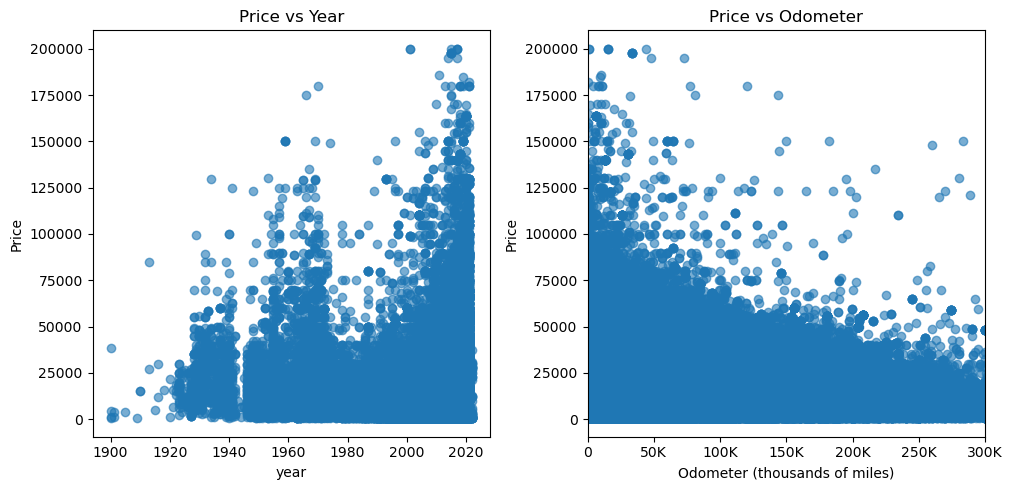

In [49]:
# Select numeric columns
numeric_cols = vehicles_clean.select_dtypes(include=[np.number]).columns.tolist()

# Remove 'id' and 'price' from numeric columns 
numeric_cols = [col for col in numeric_cols if col not in ['id', 'price']]

# Create scatter plots
num_plots = len(numeric_cols)
rows = (num_plots // 3) + 1  # Arrange plots in rows of 3
plt.figure(figsize=(15, rows * 5))  # Adjust overall figure size


for i, col in enumerate(numeric_cols):
    plt.subplot(rows, 3, i + 1)
    plt.scatter(vehicles_clean[col], vehicles_clean['price'], alpha=0.6)
    plt.title(f"Price vs {col.capitalize()}")
    plt.xlabel(col)
    plt.ylabel('Price')
    
    # Special formatting for odometer
    if col == 'odometer':
        # Format x-axis to show readable numbers
        plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(
            lambda x, p: f'{int(x/1000)}K' if x >= 1000 else f'{int(x)}'
        ))
        plt.xlabel('Odometer (thousands of miles)')
        # Limit to realistic range
        plt.xlim(0, 300_000)
        
        
plt.tight_layout()
plt.show()

## Key Observations
- Positive relationship between price and year
- Negative relationship between price and odometer

### 2.6 Categorical Analysis

In [50]:
categorical_cols = vehicles_clean.select_dtypes(include=object).columns.tolist()

categorical_cols

['region',
 'manufacturer',
 'model',
 'fuel',
 'title_status',
 'transmission',
 'VIN',
 'type',
 'paint_color',
 'state']

### Analyzing the categories ###

Below implements a function to gauge the number of categories, average, and price ranges given a categorical value, to better gauge which columns impact price.

In [51]:
def categorical_analysis(df, categorical_cols):    
    results = []
    
    for col in categorical_cols:
        if col in df.columns and df[col].notna().sum() > 100:
            
            # Basic stats
            group_stats = df.groupby(col)['price'].agg(['mean', 'std', 'count'])
            group_stats = group_stats[group_stats['count'] >= 20]  # Filter small groups
            
            if len(group_stats) > 0:
                results.append({
                    'category': col,
                    'n_categories': len(group_stats),
                    'min_avg_price': group_stats['mean'].min(),
                    'max_avg_price': group_stats['mean'].max(),
                    'price_range': group_stats['mean'].max() - group_stats['mean'].min(),
                    'highest_price_category': group_stats['mean'].idxmax(),
                    'lowest_price_category': group_stats['mean'].idxmin()
                })
    
    summary_df = pd.DataFrame(results).sort_values('price_range', ascending=False)
    
    print("CATEGORICAL VARIABLE IMPACT SUMMARY:")
    print("="*80)
    for _, row in summary_df.head(10).iterrows():
        print(f"\n{row['category'].capitalize()}:")
        print(f"  • Price range: ${row['min_avg_price']:,.0f} - ${row['max_avg_price']:,.0f} (${row['price_range']:,.0f} spread)")
        print(f"  • Highest: {row['highest_price_category']} (${row['max_avg_price']:,.0f})")
        print(f"  • Lowest: {row['lowest_price_category']} (${row['min_avg_price']:,.0f})")
    
    return summary_df


categorical_cols.remove('VIN')
summary = categorical_analysis(vehicles_clean, categorical_cols=categorical_cols)
summary

CATEGORICAL VARIABLE IMPACT SUMMARY:

Model:
  • Price range: $500 - $139,950 ($139,450 spread)
  • Highest: Mclaren 570GT W/ Upgrades ($139,950)
  • Lowest: Flexible Down Payments ($500)

Manufacturer:
  • Price range: $5,187 - $97,997 ($92,810 spread)
  • Highest: ferrari ($97,997)
  • Lowest: saturn ($5,187)

Region:
  • Price range: $9,302 - $36,226 ($26,924 spread)
  • Highest: imperial county ($36,226)
  • Lowest: siskiyou county ($9,302)

Type:
  • Price range: $9,884 - $28,784 ($18,900 spread)
  • Highest: pickup ($28,784)
  • Lowest: mini-van ($9,884)

Title_status:
  • Price range: $3,979 - $22,205 ($18,227 spread)
  • Highest: lien ($22,205)
  • Lowest: parts only ($3,979)

Fuel:
  • Price range: $15,840 - $34,029 ($18,189 spread)
  • Highest: diesel ($34,029)
  • Lowest: hybrid ($15,840)

Transmission:
  • Price range: $15,289 - $28,346 ($13,058 spread)
  • Highest: other ($28,346)
  • Lowest: manual ($15,289)

State:
  • Price range: $15,316 - $25,700 ($10,384 spread)
  • 

,category,n_categories,min_avg_price,max_avg_price,price_range,highest_price_category,lowest_price_category
2,model,2448,500.000000,139950.000000,139450.000000,Mclaren 570GT W/ Upgrades,Flexible Down Payments
1,manufacturer,40,5187.220755,97997.030303,92809.809548,ferrari,saturn
0,region,400,9302.027027,36226.356589,26924.329562,imperial county,siskiyou county
6,type,13,9883.863767,28784.217486,18900.353719,pickup,mini-van
4,title_status,6,3978.677632,22205.199858,18226.522227,lien,parts only
3,fuel,5,15840.281211,34029.197456,18188.916246,diesel,hybrid
5,transmission,3,15288.946802,28346.461088,13057.514286,other,manual
8,state,51,15315.914752,25699.622908,10383.708156,wa,ct
7,paint_color,12,13452.769573,22798.415718,9345.646145,white,green


### Displaying the Price Ranges of Various Categorical Values ###

See below for plot bar charts, displaying the top categorical columns, values, and their price ranges.


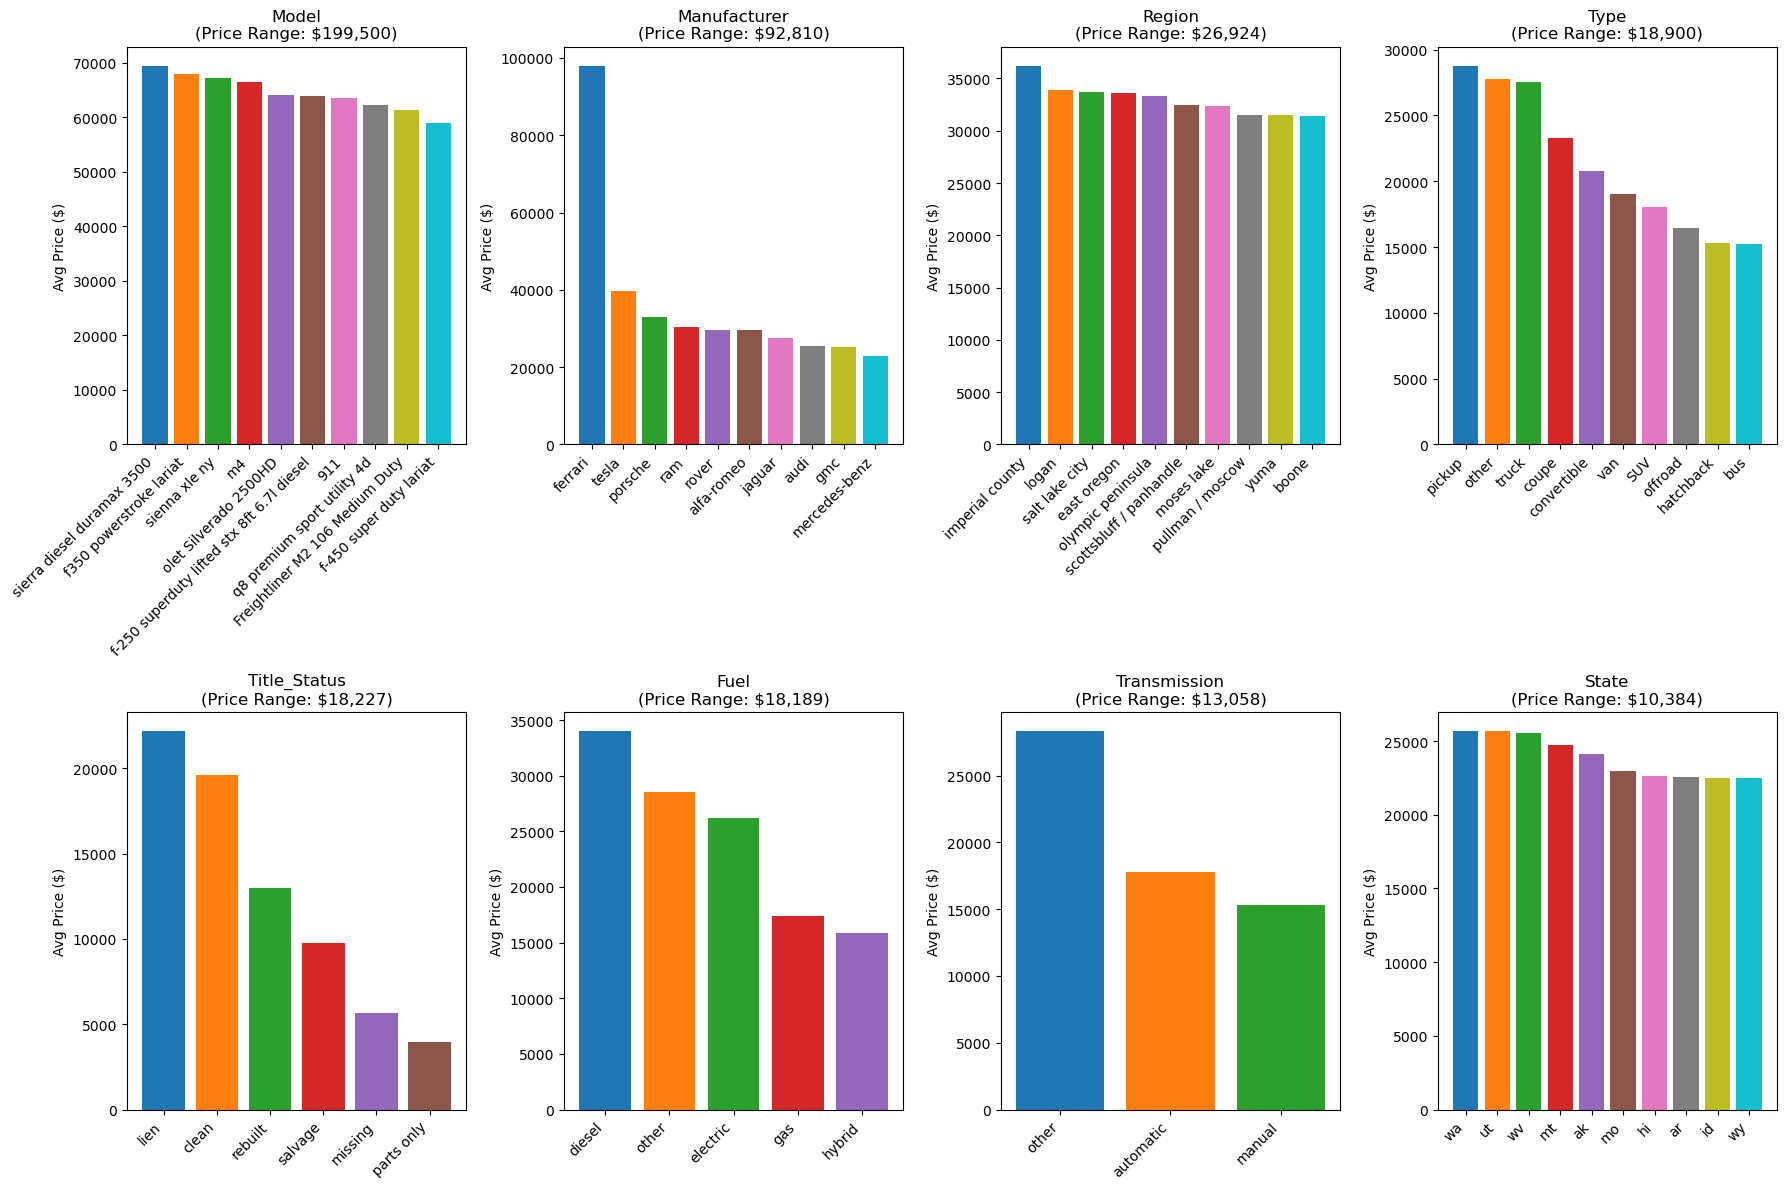

Top impactful variables: ['model', 'manufacturer', 'region', 'type', 'title_status', 'fuel', 'transmission', 'state']


In [52]:
def create_category_price_dashboard(df, top_n_vars=6):
    """Plot a dashboard displaying top categorical relationships"""
    
    # First, rank variables by price impact
    var_impact = []
    for col in categorical_cols:
        if col in df.columns and df[col].notna().sum() > 100:
            group_means = df.groupby(col)['price'].mean()
            price_range = group_means.max() - group_means.min()
            var_impact.append((col, price_range))
    
    # Sort by impact and take top N
    top_vars = sorted(var_impact, key=lambda x: x[1], reverse=True)[:top_n_vars]
    
    # Create subplot grid
    fig, axes = plt.subplots(2, 4, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, (col, impact) in enumerate(top_vars):
        ax = axes[i]
        
        # Get top categories by mean price
        category_means = df.groupby(col)['price'].agg(['mean', 'count'])
        category_means = category_means[category_means['count'] >= 30]
        top_categories = category_means.nlargest(10, 'mean')
        
        # Create bar chart
        bars = ax.bar(range(len(top_categories)), top_categories['mean'], color=plt.cm.tab10(range(len(top_categories))))
        ax.set_title(f'{col.title()}\n(Price Range: ${impact:,.0f})')
        ax.set_xticks(range(len(top_categories)))
        ax.set_xticklabels(top_categories.index, rotation=45, ha='right')
        ax.set_ylabel('Avg Price ($)')
    
    plt.tight_layout()
    plt.show()
    
    return [var[0] for var in top_vars]

# Create dashboard
top_variables = create_category_price_dashboard(vehicles_clean, top_n_vars=8)
print(f"Top impactful variables: {top_variables}")

## Key Observations

Among the 14 categorical columns, both the impact summary report and top category price dashboard display the below columns as top drivers:
- model
- manufacturer
- region
- type
- title status
- fuel
- transmission
- state

### 2.7 Handling Multicollinearity

Prior to data cleaning and model instantiation, we encode the categories to understand the potential for multicollinearity. 

Below employs a simple implementaton of target encoding for the following columns:
- model
- manufacturer
- region
- type
- title_status
- fuel
- transmission
- state

Ordinal encoder is used for condition.

In [293]:
vehicles_encoded = vehicles_clean.copy()

target_encoder_cols = categorical_cols.copy()

target_encoder_cols.remove('paint_color')


remove_columns = [col for col in vehicles_encoded.columns.tolist() if col not in target_encoder_cols + numeric_cols + ['condition', 'price']]

vehicles_encoded.drop(columns=remove_columns, inplace=True)
vehicles_encoded.dropna(inplace=True)

vehicles['model'] = vehicles['model'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)

for col in target_encoder_cols:
    vehicles_encoded[f'{col}_encoded'] = vehicles_encoded.groupby(col)['price'].transform('mean')
    vehicles_encoded[col] = pd.to_numeric(vehicles_encoded[f'{col}_encoded'].astype(float)) # Keep as float
    vehicles_encoded.drop(columns=f'{col}_encoded', inplace=True)

vehicles_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 278329 entries, 27 to 426879
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        278329 non-null  float64
 1   price         278329 non-null  int64  
 2   year          278329 non-null  float64
 3   manufacturer  278329 non-null  float64
 4   model         278329 non-null  float64
 5   fuel          278329 non-null  float64
 6   odometer      278329 non-null  float64
 7   title_status  278329 non-null  float64
 8   transmission  278329 non-null  float64
 9   type          278329 non-null  float64
 10  state         278329 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 25.5 MB


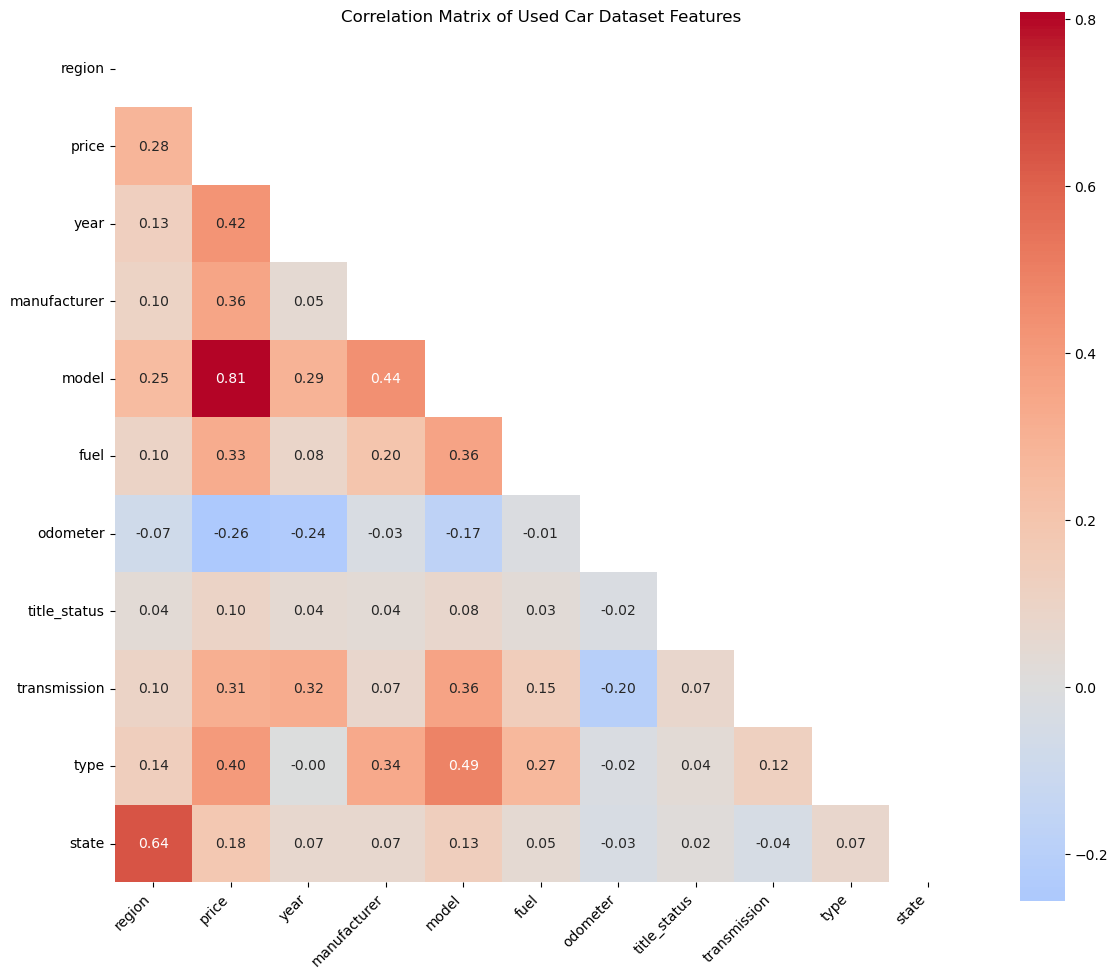

In [294]:
# Create correlation matrix of all features
correlation_matrix = vehicles_encoded.corr()

# Visualize correlation matrix
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', 
            center=0, fmt='.2f', square=True)
plt.title('Correlation Matrix of Used Car Dataset Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Key Observations

With simple target encoding applied to categorical variables, a couple observations to note from the correlation matrix:

Strong correlations with price:
- model: 0.81
- year: 0.42
- type: 0.4
- manufacturer: 0.36
- fuel: 0.33
- transmission: 0.31
- region: 0.28

Multicollinearity between, model, type, and manufacturer denotes vehicle identity cluster:
- model & type: 0.49 - model determines vehicle type
- model & manufacturer: 0.44 - model determines brand
- type & manufacturer: 0.34 - brand type associations

Multicollinearity between fuel, model, transmission and year also allude to technological advancements in vehicles:
- fuel & model: 0.36 - fuel type indicated by model
- transmission & year: 0.32 - transmission tech evolution
- transmission & model: 0.36 - model indicates transmission

Clean, independent features:
- odometer: -0.26 - higher mileage leads to lower prices
- year: 0.42 - newer cars sell at higher prices
- region: 0.28 - price ranges dependent on the region where car is sold 

With this, the following columns can be considered as dependent features:
- model
- year
- odometer
- region
- fuel

### 3. Data Preparation ###

With data preparation, unrealistic values are removed, and the model is restricted to the following column:

In [295]:
vehicles_encoded = vehicles_encoded[   
  (vehicles['year'] >= 1980) &       
  (vehicles['year'] <= 2026) &       
  (vehicles['odometer'] > 0)
]
vehicles.shape

/var/folders/zq/7j33ffkd46vd0yzyrk5qyj140000gn/T/ipykernel_8342/2668277585.py:1: UserWarning:

Boolean Series key will be reindexed to match DataFrame index.



(426880, 18)

In [296]:
model_cols = ['price', 'model', 'year', 'odometer', 'region', 'fuel', 'transmission', 'manufacturer', 'type']
## Originally, model was included but led to severe overfitting

vehicles_model = vehicles_encoded[model_cols]

vehicles_model.shape
vehicles_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274699 entries, 27 to 426879
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         274699 non-null  int64  
 1   model         274699 non-null  float64
 2   year          274699 non-null  float64
 3   odometer      274699 non-null  float64
 4   region        274699 non-null  float64
 5   fuel          274699 non-null  float64
 6   transmission  274699 non-null  float64
 7   manufacturer  274699 non-null  float64
 8   type          274699 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 21.0 MB


In [ ]:
create_category_price_dashboard(vehicles_model, top_n_vars=8)

In [297]:
X = vehicles_model.drop('price', axis=1)
y = vehicles_model['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((219759, 8), (54940, 8))

### 4. Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

### 4.1 Simple Linear Regression of Price vs. Vehicle Model

In [270]:
X_year = vehicles_model[['year']]

X_year_train, X_year_test, y_train, y_test = train_test_split(
    X_year, y, test_size=0.2, random_state=42
)

model_linreg = LinearRegression().fit(X_year_train, y_train)

mlm_preds = model_linreg.predict(X_year_test)

mlm_rmse = root_mean_squared_error(y_test, mlm_preds)
mlm_mae = mean_absolute_error(y_test, mlm_preds)

print(f"Linear Regression RMSE: {mlm_rmse:,.2f}")
print(f"Linear Regression MAE : {mlm_mae:,.2f}")

print(f"Linear Regression Coefficients: {model_linreg.coef_}")
print(f"Linear Regression Intercept: {model_linreg.intercept_}")

Linear Regression RMSE: 12,980.03
Linear Regression MAE : 9,795.14
Linear Regression Coefficients: [761.23361211]
Linear Regression Intercept: -1511446.1426549773


### 4.2 Linear Regression using All Dependent Variables

In [275]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

score = lin_reg.score(X_test, y_test)

y_pred_lr = lin_reg.predict(X_test)

rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"Linear Regression RMSE: {rmse_lr:,.2f}")
print(f"Linear Regression MAE : {mae_lr:,.2f}")

print(f"Linear Regression Coefficients: {lin_reg.coef_}")
print(f"Linear Regression Intercept: {lin_reg.intercept_}")

print(f"Linear Regression Score: {score}")

Linear Regression RMSE: 7,584.19
Linear Regression MAE : 4,751.93
Linear Regression Coefficients: [ 8.53734852e-01  3.64975969e+02 -8.37374586e-03  2.46175904e-01
  1.27548676e-01 -1.40134665e-01  4.44164512e-02  1.03681483e-01]
Linear Regression Intercept: -738327.7651187842
Linear Regression Score: 0.7191957970283211


### 4.3 Feature Selection using RFE

In [279]:
rfe = RFE(lin_reg, n_features_to_select=5)
rfe.fit(X_train, y_train)
selected_features = X_train.columns[rfe.support_]
selected_features

Index(['model', 'year', 'region', 'fuel', 'transmission'], dtype='object')

### 4.3 Linear Regression with Selected Features

In [280]:
lin_reg_w_selected_features = LinearRegression().fit(X_train[selected_features], y_train)

rfe_coef_df = pd.DataFrame({
  'feature': selected_features,
  'coefficient': lin_reg_w_selected_features.coef_
}).sort_values('coefficient', ascending=False)

y_rfe_preds = lin_reg_w_selected_features.predict(X_test[selected_features])
rfe_rmse = root_mean_squared_error(y_test, y_rfe_preds)
rfe_mae = mean_absolute_error(y_test, y_rfe_preds)

print(f"RFE RMSE: {rfe_rmse}")
print(f"RFE Mae: {rfe_mae}")
print(f"R2 score: {r2_score(y_test, y_rfe_preds)}")

rfe_coef_df

RFE RMSE: 7715.93515278005
RFE Mae: 4903.706382694739
R2 score: 0.7093552938449876


,feature,coefficient
1,year,378.716039
0,model,0.899222
2,region,0.255760
3,fuel,0.128532
4,transmission,-0.117169


### RFE Insight

While manufacturer was included in the model interpretation, RFE selects:
- year
- model
- region
- fuel
- transmission 

to possess the strongest predictive power.



### 4.4 Using StandardScaler and PCA components

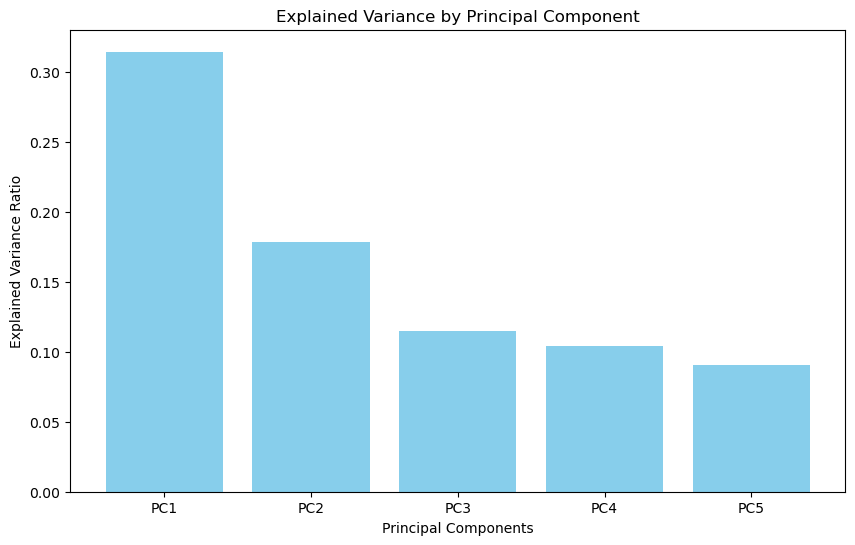

In [298]:
X = vehicles_model.drop('price', axis=1)
y = vehicles_model['price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
explained_variance = pca.explained_variance_ratio_
components = [f'PC{i+1}' for i in range(len(explained_variance))]
plt.bar(components, explained_variance, color='skyblue')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Component')
plt.show()



In [299]:
linreg_pca = LinearRegression()
linreg_pca.fit(X_pca, y)

y_pca_preds = linreg_pca.predict(X_pca)

pca_rmse = root_mean_squared_error(y, y_pca_preds)
pca_mae = mean_absolute_error(y, y_pca_preds)

print(f"RSME: {pca_rmse}")
print(f"RSME: {pca_mae}")
print(linreg_pca.coef_)

RSME: 8536.11578210693
RSME: 5638.336344262816
[7225.84340477 -740.06636622  382.37966093 -776.07438316 -333.48906036]


# 4.2 Cross-Validation for Linear Regression Model using RFE

In [300]:
cv_scores = cross_val_score(
  lin_reg_w_selected_features, X_train, y_train,
  scoring='neg_root_mean_squared_error',
  cv=5
)

rmse_cv = -cv_scores

print('Cross-validated RSME (mean +- std) when using RFE selected features: ' f"{rmse_cv.mean():,.2f} +- {rmse_cv.std():.2f}")

Cross-validated RSME (mean +- std) when using RFE selected features: 7,082.82 +- 67.68


# 4.3 Comprehensive Grid Search using Ridge, PCA, and Standard Scaler

In [301]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

ridge_pca_params = {
    'pca__n_components': [3, 5, 7, 10, 0.80, 0.85, 0.90, 0.95, 0.99],
    'ridge__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}

ridge_pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('ridge', Ridge())
])

ridge_pca_grid = GridSearchCV(
    ridge_pca_pipeline,
    ridge_pca_params,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

ridge_pca_grid.fit(X_train, y_train)

Fitting 5 folds for each of 63 candidates, totalling 315 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning:


35 fits failed out of a total of 315.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
35 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py", line 469, in fit
    Xt = self._fit(X, y

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA()), ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'pca__n_components': [3, 5, 7, 10, 0.8, 0.85, 0.9,
                                               0.95, 0.99],
                         'ridge__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0,
                                          1000.0]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [302]:
best_ridge = ridge_pca_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print(f"Best Ridge Test RMSE: {rmse_ridge:,.2f}")
print(f"Best Ridge Test MAE: {mae_ridge:,.2f}")
print(f"Best Ridge R2 Score: {r2_score(y_test, y_pred_ridge)}")

Best Ridge Test RMSE: 6,978.61
Best Ridge Test MAE: 4,504.25
Best Ridge R2 Score: 0.7604756004591708


Lasso Regression with Grid Search

In [303]:
lasso_pca_params = {
    'pca__n_components': [3, 5, 7, 10, 0.80, 0.85, 0.90, 0.95, 0.99],
    'lasso__alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'lasso__max_iter': [10000]  
}
lasso_pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('pca', PCA()),
    ('lasso', Lasso())
])
lasso_pca_grid = GridSearchCV(
    lasso_pca_pipeline,
    lasso_pca_params,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

lasso_pca_grid.fit(X_train, y_train)

print("Best Lasso params:", lasso_pca_grid.best_params_)
print("Best Lasso CV RMSE:", -lasso_pca_grid.best_score_)

best_lasso = lasso_pca_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

rmse_lasso = root_mean_squared_error(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print(f"Best Lasso Test RMSE: {rmse_lasso:,.2f}")
print(f"Best Lasso Test MAE : {mae_lasso:,.2f}")
print(f"Best Lasso Test RSME: {r2_score(y_test, y_pred_lasso)}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning:


30 fits failed out of a total of 270.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
30 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/pipeline.py", line 469, in fit
    Xt = self._fit(X, y

Best Lasso params: {'lasso__alpha': 0.001, 'lasso__max_iter': 10000, 'pca__n_components': 0.99}
Best Lasso CV RMSE: 7082.822401078842
Best Lasso Test RMSE: 6,978.61
Best Lasso Test MAE : 4,504.25
Best Lasso Test RSME: 0.7604755999101335


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

In [304]:
results = pd.DataFrame({
    'model': ['Linear Regression using All Features', 'Linear Regression Using RFE', 'Ridge Regression using StandardScaler, PCA and GridsearchCV', 'Lasso Regression using StandardScaler, PCA and GridsearchCV', 'Linear Regression Using PCA'],
    'RMSE': [rmse_lr, rfe_rmse, rmse_ridge, rmse_lasso, pca_rmse],
    'MAE': [mae_lr, rfe_mae, mae_ridge, mae_lasso, pca_mae]
})

print(results)

                                               model         RMSE          MAE
0               Linear Regression using All Features  7584.189266  4751.934321
1                        Linear Regression Using RFE  7715.935153  4903.706383
2  Ridge Regression using StandardScaler, PCA and...  6978.611954  4504.254063
3  Lasso Regression using StandardScaler, PCA and...  6978.611962  4504.254037
4                        Linear Regression Using PCA  8536.115782  5638.336344


In [305]:
## Choose the model with the lowest RMSE for interpretation

best_model = results[results['RMSE'] == results['RMSE'].min()]

print(f"Best model is {best_model['model']}")

Best model is 2    Ridge Regression using StandardScaler, PCA and...
Name: model, dtype: object


In [306]:
coef_df = pd.DataFrame({
    'feature': X.columns.tolist(),
    'coefficient': best_ridge.named_steps['pca'].components_.T @ best_ridge.named_steps['ridge'].coef_
}).sort_values(by='coefficient', ascending=False)

print(f"Best n_components for PCA is {best_ridge.named_steps['pca'].n_components_}")
print(f"Best ridge alpha is {best_ridge.named_steps['ridge'].alpha}")
print(coef_df)

Best n_components for PCA is 8
Best ridge alpha is 0.1
        feature  coefficient
0         model  8924.679608
1          year  4581.809886
7          type   891.386031
3        region   836.422013
4          fuel   830.958915
6  manufacturer   418.479305
2      odometer -1034.962495
5  transmission -1072.035207


In [307]:
from sklearn.inspection import permutation_importance
import plotly.express as px

perm_importance = permutation_importance(best_ridge, X, y, n_repeats = 10)

df = pd.DataFrame(perm_importance['importances'])

df = df.T
df.columns = X.columns.tolist()

px.box(data_frame=df, orientation='h', title = 'Feature importance for Used Car Price Prediction')

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

### Key Business Insights
Price Prediction Accuracy: The best model predicts used vehicle prices within +/- $6,798 RSME, i.e. 68% of predictions are within ~$7,000 of the actual price.

What Drives Car Price? 
- Specific car model -> 75-80% of price determination
- Year (Age) -> ~20% of price determination
- Everything else -> ~5% combined (region, milage, etc.)

## Actionable Business Insights:
- The specific car model (and likely brand) determines 3/4 of the price
- Cars lose significant value per year, but specific models matter more than generic age
- Regions have a small impact (~5%) on price - whether the car is from Bevery Hills, CA likely has little impact.

## Pricing Hierarchy
- Consider market averages given the model and brand
- Adjust for age with recency releative to higher premium
- Lower mileage = lower price
- Transmission Type
- Regional market differences

## For Acquisition Decisions:
- Prioritize popular models with strong resale value
- Age vs Model Tradeoff: A well reviewed model may outperforma less desirable new car

## Feature Engineering Insights
- Simple target encoding created price scaled ranges created seemingly inflated, but appropriate coefficients
- PCA coefficients operate on price-magnitude principal components

### Further Analysis and Recommendations for Product Teams

## Immediate Actions
1. Implement model-based pricing alerts when inventory deviates from predicted prices
2. Prioritize high-value, predictable models for acquisition strategy
3. Automate initial pricing using PCA + Ridge model

## Model improvements
- Address overfitting: leverage segmentation using manufacturer and vehicle type
- Feature engineering: Implement vehicle model independent features
- Validation strategy: Rather than random samples, hold out entire car models
